In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
from IPython.display import display, HTML
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
from decimal import Decimal

# Get multiple outputs in the same cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Ignore all warnings
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings(action='ignore', category=DeprecationWarning)
pd.set_option('display.max_columns', None)


## Data preparation

In [3]:
# Read in the data 
# We have two dataframes with same column but different data 
# I believe we should have one dataframe contain information about both dataframes (presence and absence)

# Here I was reading in old data. Just want to show Kyle the difference between old and new data
# presence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/points_data/points_of_presence_test_old.csv', delimiter=';')
# absence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/points_data/points_of_absence_test_old.csv', delimiter=';')

presence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/points_data/points_of_presence_test_new.csv', delimiter=';')
absence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/points_data/points_of_absence_test_new.csv', delimiter=';')


print("Presence info", presence_df.shape)
print("Absence info", absence_df.shape)

Presence info (46110, 26)
Absence info (46110, 26)


In [4]:
# Head for points of presence data
print("Points of presence")
presence_df.head()

# Head for points of absence data
print("Points of absence")
absence_df.head()

Points of presence


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,"19,552906066300000","-33,503039127100003","423,8035889","1262675,2500000","7,6203117","11,7305155","21,6820641","155,2328949","294957,0312500","0,1973951","15,9867964","9,6832962","23,0573425","204,5053253","1866,6802979","9051,3925781","262,1053772","754,4794922","579,4953003","122,6880951","67,2119293","123,3386612","0,3997020","0,0000000","0,0000000"
1,2,"19,554065257300000","-33,502591599200002","418,8850098","1238057,0000000","7,5433488","13,2344179","24,5836411","151,8608856","295034,0312500","0,1286995","15,8695059","9,6180811","22,8775139","206,5435181","1837,9093018","9064,5273438","255,0745544","753,3905029","596,1103516","122,8667297","67,3483429","124,2754517","0,4077038","0,0000000","0,0000000"
2,3,"19,553220609499999","-33,504088723999999","408,7989197","1293872,6250000","7,6285295","9,4727755","17,4985867","153,0930939","294792,1250000","0,1446818","16,0426788","9,7182827","23,1365280","204,9259338","1879,4543457","9633,4052734","271,9782715","760,3276978","598,3022461","121,0519714","66,8941498","119,2392654","0,4207691","0,0000000","0,0000000"
3,4,"19,554527855100002","-33,504862308200003","393,0697327","1312602,2500000","7,5401411","7,9924750","14,8219433","147,5858154","294676,7812500","0,0504019","16,0228729","9,7115231","23,0989895","207,0958252","1873,5273438","10316,7373047","279,1886597","766,2723389","630,4938965","119,1085968","66,6778259","115,3868942","0,4456471","0,0000000","0,0000000"
4,5,"19,553802071600000","-33,504471387300001","400,9482727","1303012,5000000","7,5930171","8,7492332","16,1888485","150,6344604","294734,6562500","0,0999071","16,0353279","9,7162180","23,1218605","205,8853760","1877,1494141","9953,2421875","275,1390381","763,1566162","614,1897583","120,1982269","66,7786255","117,3420486","0,4328750","0,0000000","0,0000000"


Points of absence


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,"21,568219575073385","-32,845436310137586","667,1586914","1483005,1250000","9,0135527","2,1335182","3,4945560","134,8665924","297321,6562500","-0,0866669","18,6504345","11,5633831","26,4917850","40,3150101","2625,9384766","1005,2607422","52,6314621","693,5087891","46,7836609","138,2878418","74,7023392","168,2033691","0,0878413","0,0240000","0,0480000"
1,2,"19,929761337216007","-34,669140494937835","17,7988892","1334560,0000000","8,8747396","1,1062130","1,7273655","152,5726471","27658,9550781","-0,0117142","18,1583271","13,7313309","23,9642906","231,7956696","2157,1762695","4419,1899414","245,2176666","639,4815674","445,3425293","193,3942566","69,1715851","167,1241913","0,2856699","0,0037139","0,0037139"
2,3,"20,853933888937888","-33,715715851505308","487,1492310","1444049,5000000","7,2310748","2,3288376","4,0689297","131,4290314","225323,4218750","-0,0191663","17,1582813","10,4304876","25,2325687","118,7681351","2206,4777832","1042,4602051","178,8755035","651,9295044","232,8902435","191,7061310","77,0000000","156,5092010","0,1098227","0,0339411","0,0480000"
3,4,"19,913425410354478","-33,069432348823796","595,4059448","1477565,2500000","8,2927780","1,5052947","2,0903606","157,0732117","388392,0000000","-0,0615444","17,6923790","10,1807861","26,0774708","39,0124130","2364,7324219","1129,3968506","68,1352386","713,8799438","87,1456985","150,1565552","80,7177124","135,9635010","0,1504509","0,0291952","0,0000000"
4,5,"21,591854189219532","-32,879877811112067","677,4995728","1508521,2500000","7,9686489","2,6092782","4,5575848","294,1683960","296658,8750000","0,0365601","18,5143147","11,5140390","26,2532215","39,0649796","2588,6350098","997,8342285","49,6851540","705,8392944","27,6697407","126,7174072","73,2194366","167,4905548","0,0906056","0,0008665","0,0378356"


In [5]:
# Describe the data
print("Points of presence description")
presence_df.describe()

# I think the other columns are not included due to data type being object
print("Points of absence description")
absence_df.describe()

Points of presence description


,OID_
count,46110.000000
mean,23055.500000
std,13310.954793
min,1.000000
25%,11528.250000
50%,23055.500000
75%,34582.750000
max,46110.000000


Points of absence description


,OID_
count,46110.000000
mean,23055.500000
std,13310.954793
min,1.000000
25%,11528.250000
50%,23055.500000
75%,34582.750000
max,46110.000000


In [6]:
# Check for Null values 
print("Null result for presence")
presence_df.isnull().sum()

print("Null results for absence")
absence_df.isnull().sum()

Null result for presence


OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                2
sudem_1000m_albers_curvature_wc                   2
composite_temp_mean_1000m_k30_wc                  4
composite_temp_min_1000m_k30_wc                   4
composite_temp_max_1000m_k30_wc                   4
composite_rainfall_sum_1000m_k30_wc               2
composite_gdd_grapes_1000m_wc                     4
composite_AETI_1000m_albers_wc                    0
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

Null results for absence


OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_k30_wc                  1
composite_temp_min_1000m_k30_wc                   1
composite_temp_max_1000m_k30_wc                   1
composite_rainfall_sum_1000m_k30_wc               0
composite_gdd_grapes_1000m_wc                     1
composite_AETI_1000m_albers_wc                    2
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

In [7]:
# Adding suitability column to both df and assigning a value of 1 to where there vineyards and 0 where there are no vineyards

presence_df['suitability'] = 1  # Highly suitable (characteristics for suitable vineyards)
absence_df['suitability'] = 0  # Less suitable (characteristics for potential suitability/ non suitability)

# Checking size of the dataframes
print("Checking size of the dataframes")
presence_df['suitability'].value_counts()
absence_df['suitability'].value_counts()

Checking size of the dataframes


suitability
1    46110
Name: count, dtype: int64

suitability
0    46110
Name: count, dtype: int64

In [8]:
# Let me try out to fill in null values using linear interpolation based on the surround non-null values
# This does not seem to work, could be that the data is still seen as an object and not a float
# absence_df['composite_temp_mean_1000m_k30_wc'].interpolate(method='linear', inplace=True)

In [9]:
# Combine the datasets
# other combining functions include merge() join()
# combined_df = pd.concat([presence_df, absence_df], axis=0) (This concatinates my df as strings which resulted in some values being Nan, results in twice as many points)

# merge function combines the df using a common column and then renames columns that were same using x o y suffixes 
# results in 46110 points (original value)
# creates separate column called suitability_x and suitability_y 
# concatinating the df vertically and axis=0 adds rows, axis = 1 adds columns

combined_df = pd.concat([presence_df, absence_df], axis=0, ignore_index=True)

print("combined dataframe")
combined_df


combined dataframe


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
0,1,"19,552906066300000","-33,503039127100003","423,8035889","1262675,2500000","7,6203117","11,7305155","21,6820641","155,2328949","294957,0312500","0,1973951","15,9867964","9,6832962","23,0573425","204,5053253","1866,6802979","9051,3925781","262,1053772","754,4794922","579,4953003","122,6880951","67,2119293","123,3386612","0,3997020","0,0000000","0,0000000",1
1,2,"19,554065257300000","-33,502591599200002","418,8850098","1238057,0000000","7,5433488","13,2344179","24,5836411","151,8608856","295034,0312500","0,1286995","15,8695059","9,6180811","22,8775139","206,5435181","1837,9093018","9064,5273438","255,0745544","753,3905029","596,1103516","122,8667297","67,3483429","124,2754517","0,4077038","0,0000000","0,0000000",1
2,3,"19,553220609499999","-33,504088723999999","408,7989197","1293872,6250000","7,6285295","9,4727755","17,4985867","153,0930939","294792,1250000","0,1446818","16,0426788","9,7182827","23,1365280","204,9259338","1879,4543457","9633,4052734","271,9782715","760,3276978","598,3022461","121,0519714","66,8941498","119,2392654","0,4207691","0,0000000","0,0000000",1
3,4,"19,554527855100002","-33,504862308200003","393,0697327","1312602,2500000","7,5401411","7,9924750","14,8219433","147,5858154","294676,7812500","0,0504019","16,0228729","9,7115231","23,0989895","207,0958252","1873,5273438","10316,7373047","279,1886597","766,2723389","630,4938965","119,1085968","66,6778259","115,3868942","0,4456471","0,0000000","0,0000000",1
4,5,"19,553802071600000","-33,504471387300001","400,9482727","1303012,5000000","7,5930171","8,7492332","16,1888485","150,6344604","294734,6562500","0,0999071","16,0353279","9,7162180","23,1218605","205,8853760","1877,1494141","9953,2421875","275,1390381","763,1566162","614,1897583","120,1982269","66,7786255","117,3420486","0,4328750","0,0000000","0,0000000",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92215,46106,"23,495416236370261","-31,793901584990124","1162,4739990","1597666,8750000","9,1995277","1,0253339","0,8319384","133,0602570","411619,1250000","-0,0163932","16,7675591","9,2552242","24,7319012","154,0359039","2195,5539551","1137,9976807","63,1911736","599,7850342","71,1006393","203,1139832","80,7703247","197,1394501","0,1382415","0,0000000","0,0480000",0
92216,46107,"22,715602905349840","-31,872963273935909","1323,8831787","1618685,0000000","9,0564175","0,4957476","0,8652785","115,7642212","452081,5625000","0,0332791","16,4653759","10,1061459","23,1868896","73,6929855","2037,0895996","1219,7507324","67,8278656","607,3751831","68,1308975","183,7181549","78,4343643","208,9066467","0,1322167","0,0034267","0,0034267",0
92217,46108,"22,474740777764737","-31,765556181672423","1554,3348389","1665689,3750000","7,5474143","1,6631688","2,9036171","149,8292694","478055,4375000","-0,0227279","15,5771427","9,6843328","21,7293301","53,4433708","1825,0356445","1559,5961914","73,2299728","597,6461792","62,1008034","180,7212372","77,8456345","221,6186066","0,1539931","0,0453529","0,0138854",0
92218,46109,"23,662031286414788","-31,911282061617783","1131,0124512","1599360,2500000","8,4490862","1,8949413","3,2963638","337,2799683","397868,5312500","0,0661309","16,7568569","8,8685846","

In [10]:
# Data types of the columns before conversion
combined_df.dtypes

OID_                                               int64
POINT_X                                           object
POINT_Y                                           object
sudem_1000m_albers_filled_wc                      object
sudem_1000m_albers_potential_solar_rad_wh2m_wc    object
sudem_1000m_albers_twi_d8_wc                      object
sudem_1000m_albers_slope_degree_wc                object
sudem_1000m_albers_slope_wc                       object
sudem_1000m_albers_aspect_wc                      object
sudem_1000m_albers_flow_network_wc                object
sudem_1000m_albers_curvature_wc                   object
composite_temp_mean_1000m_k30_wc                  object
composite_temp_min_1000m_k30_wc                   object
composite_temp_max_1000m_k30_wc                   object
composite_rainfall_sum_1000m_k30_wc               object
composite_gdd_grapes_1000m_wc                     object
composite_AETI_1000m_albers_wc                    object
nitrogen_0_to_5cm_1000m_albers_

In [11]:
# Remove commas from the values and convert to float/double
def clean_and_convert(x):
    return x.str.replace(',', '').astype('float')

columns_to_convert = ['POINT_X', 'POINT_Y', 'sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
                        'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc', 'sudem_1000m_albers_slope_wc',
                        'sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
                        'composite_temp_mean_1000m_k30_wc', 'composite_temp_min_1000m_k30_wc', 'composite_temp_max_1000m_k30_wc',
                        'composite_rainfall_sum_1000m_k30_wc', 'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc',
                        'nitrogen_0_to_5cm_1000m_albers_wc', 'sand_0_to_5cm_1000m_albers_wc', 'soc_0_to_5cm_1000m_albers_wc',
                        'clay_content_0_to_5cm_1000m_albers_wc', 'soil_ph_0_to_5cm_1000m_albers_wc', 'silt_0_to_5cm_1000m_albers_wc',
                        'ndvi_wc', 'euclidean_distance_roads_1000m_albers_wc', 'euclidean_distance_rivers_1000m_albers_wc'] # Add all relevant columns
for col in columns_to_convert:
    combined_df[col] = clean_and_convert(combined_df[col])

In [12]:
# Data types of the columns after conversion
combined_df.dtypes

OID_                                                int64
POINT_X                                           float64
POINT_Y                                           float64
sudem_1000m_albers_filled_wc                      float64
sudem_1000m_albers_potential_solar_rad_wh2m_wc    float64
sudem_1000m_albers_twi_d8_wc                      float64
sudem_1000m_albers_slope_degree_wc                float64
sudem_1000m_albers_slope_wc                       float64
sudem_1000m_albers_aspect_wc                      float64
sudem_1000m_albers_flow_network_wc                float64
sudem_1000m_albers_curvature_wc                   float64
composite_temp_mean_1000m_k30_wc                  float64
composite_temp_min_1000m_k30_wc                   float64
composite_temp_max_1000m_k30_wc                   float64
composite_rainfall_sum_1000m_k30_wc               float64
composite_gdd_grapes_1000m_wc                     float64
composite_AETI_1000m_albers_wc                    float64
nitrogen_0_to_

In [13]:
# Describe the data and check for nulls again

combined_df.describe()
combined_df.head(10)
combined_df['suitability'].value_counts()

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
count,92220.000000,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.221800e+04,9.221800e+04,9.221500e+04,9.221500e+04,9.221500e+04,9.221800e+04,9.221500e+04,9.221800e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.221900e+04,9.222000e+04,9.222000e+04,92220.000000
mean,23055.500000,1.991152e+16,-3.325236e+16,4.101864e+09,1.418921e+13,8.022344e+07,5.848445e+07,1.052639e+08,1.839564e+09,1.955895e+12,1.041588e+04,1.725319e+08,1.140676e+08,2.418807e+08,2.272695e+09,2.149436e+10,4.743152e+10,2.089597e+09,7.159507e+09,3.368353e+09,1.399673e+09,6.783928e+08,1.253061e+09,3.024819e+06,7.094002e+04,2.092084e+05,0.500000
std,13310.882622,1.435040e+15,8.269371e+14,3.606766e+09,8.119734e+11,1.695695e+07,6.348223e+07,1.248349e+08,7.388622e+08,1.194311e+12,1.664752e+06,1.175132e+07,1.230188e+07,1.721300e+07,1.767974e+09,2.784699e+09,2.511118e+10,9.074787e+08,1.039704e+09,1.678898e+09,4.389411e+08,9.280704e+07,4.127978e+08,1.214260e+06,1.615123e+05,3.990480e+05,0.500003
min,1.000000,1.784222e+16,-3.479102e+16,7.995646e+06,7.840468e+12,2.934461e+07,1.456120e+05,0.000000e+00,1.825276e+07,7.564701e+09,-3.864582e+07,1.022119e+08,5.271194e+07,1.498652e+08,1.918540e+08,6.198793e+09,2.083687e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.904425e+06,0.000000e+00,0.000000e+00,0.000000
25%,11528.000000,1.885598e+16,-3.383419e+16,1.599260e+09,1.377091e+13,7.006381e+07,1.791921e+07,2.958823e+07,1.290015e+09,7.544963e+11,-5.271120e+05,1.674162e+08,1.069724e+08,2.319447e+08,9.302700e+08,2.011494e+10,2.678496e+10,1.291246e+09,6.624371e+09,2.042049e+09,1.048615e+09,6.326824e+08,9.486628e+08,1.947184e+06,0.000000e+00,0.000000e+00,0.000000
50%,23055.500000,1.934755e+16,-3.355873e+16,2.589759e+09,1.400370e+13,7.782132e+07,3.464592e+07,5.995954e+07,1.858715e+09,2.090835e+12,-1.051300e+04,1.737876e+08,1.151319e+08,2.446473e+08,1.753765e+09,2.189730e+10,4.762086e+10,2.272408e+09,7.296147e+09,3.515780e+09,1.327938e+09,6.755449e+08,1.257139e+09,3.152570e+06,0.000000e+00,0.000000e+00,0.500000
75%,34583.000000,2.066067e+16,-3.281562e+16,5.979932e+09,1.456098e+13,8.706856e+07,7.371059e+07,1.300345e+08,2.401005e+09,2.880476e+12,5.011352e+05,1.797482e+08,1.247980e+08,2.530821e+08,3.057851e+09,2.318544e+10,6.680187e+10,2.761381e+09,7.909634e+09,4.649284e+09,1.747144e+09,7.447822e+08,1.523610e+09,3.973904e+06,0.000000e+00,2.400000e+05,1.000000
max,46110.000000,2.416317e+16,-3.045928e+16,2.139788e+10,1.842116e+13,2.577966e+08,5.747625e+08,1.590186e+09,3.585314e+09,5.014858e+12,4.648477e+07,1.986714e+08,1.386483e+08,2.824381e+08,2.071323e+10,2.853351e+10,1.343031e+11,5.020669e+09,8.782336e+09,1.075481e+10,3.137687e+09,8.700000e+08,3.450554e+09,6.844580e+06,1.609969e+06,5.468445e+06,1.000000


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
0,1,1.955291e+16,-3.350304e+16,4.238036e+09,1.262675e+13,76203117.0,117305155.0,216820641.0,1.552329e+09,2.949570e+12,1973951.0,159867964.0,96832962.0,230573425.0,2.045053e+09,1.866680e+10,9.051393e+10,2.621054e+09,7.544795e+09,5.794953e+09,1.226881e+09,672119293.0,1.233387e+09,3997020.0,0.0,0.0,1
1,2,1.955407e+16,-3.350259e+16,4.188850e+09,1.238057e+13,75433488.0,132344179.0,245836411.0,1.518609e+09,2.950340e+12,1286995.0,158695059.0,96180811.0,228775139.0,2.065435e+09,1.837909e+10,9.064527e+10,2.550746e+09,7.533905e+09,5.961104e+09,1.228667e+09,673483429.0,1.242755e+09,4077038.0,0.0,0.0,1
2,3,1.955322e+16,-3.350409e+16,4.087989e+09,1.293873e+13,76285295.0,94727755.0,174985867.0,1.530931e+09,2.947921e+12,1446818.0,160426788.0,97182827.0,231365280.0,2.049259e+09,1.879454e+10,9.633405e+10,2.719783e+09,7.603277e+09,5.983022e+09,1.210520e+09,668941498.0,1.192393e+09,4207691.0,0.0,0.0,1
3,4,1.955453e+16,-3.350486e+16,3.930697e+09,1.312602e+13,75401411.0,79924750.0,148219433.0,1.475858e+09,2.946768e+12,504019.0,160228729.0,97115231.0,230989895.0,2.070958e+09,1.873527e+10,1.031674e+11,2.791887e+09,7.662723e+09,6.304939e+09,1.191086e+09,666778259.0,1.153869e+09,4456471.0,0.0,0.0,1
4,5,1.955380e+16,-3.350447e+16,4.009483e+09,1.303012e+13,75930171.0,87492332.0,161888485.0,1.506345e+09,2.947347e+12,999071.0,160353279.0,97162180.0,231218605.0,2.058854e+09,1.877149e+10,9.953242e+10,2.751390e+09,7.631566e+09,6.141898e+09,1.201982e+09,667786255.0,1.173420e+09,4328750.0,0.0,0.0,1
5,6,1.955539e+16,-3.350434e+16,3.929556e+09,1.292736e+13,74694476.0,94806614.0,176620884.0,1.451942e+09,2.947868e+12,184483.0,159648495.0,96773806.0,230120525.0,2.086324e+09,1.859454e+10,1.022217e+11,2.772023e+09,7.646024e+09,6.262465e+09,1.187008e+09,669140091.0,1.173485e+09,4472376.0,0.0,0.0,1
6,7,1.954867e+16,-3.350351e+16,4.492798e+09,1.308277e+13,79151511.0,92332220.0,167037067.0,1.692341e+09,2.948598e+12,4545936.0,163066292.0,98572607.0,235542793.0,1.964917e+09,1.946126e+10,8.380438e+10,2.739886e+09,7.516667e+09,5.041112e+09,1.239612e+09,670668106.0,1.246413e+09,3580814.0,0.0,0.0,1
7,8,1.954951e+16,-3.350364e+16,4.407378e+09,1.305374e+13,78684268.0,92777996.0,168557510.0,1.662918e+09,2.948440e+12,3933786.0,162563858.0,98308353.0,234747353.0,1.981157e+09,1.933439e+10,8.615666e+10,2.735403e+09,7.532825e+09,5.217081e+09,1.234279e+09,670287781.0,1.236204e+09,3707972.0,0.0,0.0,1
8,9,1.954994e+16,-3.350430e+16,4.260967e+09,1.319490e+13,78834538.0,81352720.0,147787905.0,1.644470e+09,2.947412e+12,3306450.0,162636909.0,98376637.0,234814281.0,1.988653e+09,1.934608e+10,9.001918e+10,2.781522e+09,7.568440e+09,5.375775e+09,1.224413e+09,668292389.0,1.211104e+09,3902777.0,0.0,0.0,1
9,10,1.955141e+16,-3.350357e+16,4.281077e+09,1.290337e+13,77370205.0,100277634.0,183952274.0,1.598450e+09,2.948639e+12,2763281.0,161263504.0,97607546.0,232715969.0,2.018063e+09,1.900974e+10,8.992550e+10,2.698920e+09,7.553724e+09,5.572335e+09,1.226256e+09,670485764.0,1.224548e+09,3911792.0,0.0,0.0,1


suitability
1    46110
0    46110
Name: count, dtype: int64

In [14]:
# check for null in the combined_df
combined_df.isnull().sum()

OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                2
sudem_1000m_albers_curvature_wc                   2
composite_temp_mean_1000m_k30_wc                  5
composite_temp_min_1000m_k30_wc                   5
composite_temp_max_1000m_k30_wc                   5
composite_rainfall_sum_1000m_k30_wc               2
composite_gdd_grapes_1000m_wc                     5
composite_AETI_1000m_albers_wc                    2
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

In [15]:
# sort the dataframes by POINT_X and POINT_Y
combined_df = combined_df.sort_values(by=['POINT_X', 'POINT_Y'])

In [16]:
combined_df

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
88805,42696,1.784222e+16,-3.109268e+16,1.720325e+09,1.446455e+13,85599298.0,13321152.0,23020825.0,2.827821e+09,1.257939e+11,-394368.0,182115116.0,130868692.0,244431610.0,2.349295e+08,2.150922e+10,1.088020e+10,9.518323e+08,7.633519e+09,2.318308e+09,1.319828e+09,750000000.0,1.046653e+09,1877172.0,847469.0,999440.0,0
89145,43036,1.784760e+16,-3.114216e+16,1.217931e+09,1.437265e+13,115160437.0,5108960.0,8917351.0,2.604285e+09,9.141755e+10,-105455.0,183249855.0,131541634.0,246169014.0,2.439471e+08,2.177284e+10,8.187808e+09,9.969108e+08,7.398016e+09,2.455862e+09,1.353827e+09,770919113.0,1.247820e+09,1785192.0,634410.0,581069.0,0
88892,42783,1.784868e+16,-3.119220e+16,8.257578e+08,1.427649e+13,99444466.0,11115127.0,19402251.0,2.509378e+09,4.899702e+10,-164494.0,183522816.0,131790533.0,246443825.0,2.548387e+08,2.181080e+10,1.083154e+10,1.147600e+09,7.387534e+09,1.982925e+09,1.330015e+09,769588165.0,1.284216e+09,2062055.0,240000.0,284776.0,0
90269,44160,1.785629e+16,-3.113408e+16,1.392830e+09,1.437422e+13,100664911.0,14459208.0,25242319.0,2.411542e+09,1.068361e+11,721234.0,182842541.0,131238708.0,245632172.0,2.447784e+08,2.168240e+10,7.323602e+09,1.000031e+09,7.196653e+09,2.384879e+09,1.614537e+09,775690918.0,1.181008e+09,1794927.0,706759.0,586224.0,0
89928,43819,1.786152e+16,-3.120829e+16,1.110866e+09,1.429746e+13,89684668.0,17395540.0,30357723.0,2.293358e+09,6.184510e+10,533753.0,183013859.0,131470766.0,245675144.0,2.625352e+08,2.167835e+10,1.492649e+10,1.188353e+09,7.335343e+09,1.951663e+09,1.367283e+09,764708633.0,1.299836e+09,2124592.0,0.0,240000.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85674,39565,2.414193e+16,-3.197784e+16,1.693106e+10,1.685274e+13,68264027.0,77459559.0,136329851.0,8.307907e+08,2.880866e+12,-656721.0,137853813.0,76492152.0,202388363.0,1.897601e+09,1.477586e+10,3.446858e+10,1.497977e+09,5.450258e+09,1.568374e+09,2.242411e+09,724821548.0,2.307331e+09,1911884.0,74891.0,308390.0,0
85333,39224,2.414235e+16,-3.197137e+16,1.637564e+10,1.758190e+13,79207773.0,109113531.0,192808113.0,1.173686e+08,1.708540e+12,-1514141.0,137741642.0,76406660.0,202239685.0,1.898744e+09,1.475690e+10,3.410915e+10,1.433225e+09,5.427056e+09,1.479015e+09,2.256606e+09,731278305.0,2.316338e+09,2012398.0,64642.0,340628.0,0
86102,39993,2.414907e+16,-3.198149e+16,1.621016e+10,1.655597e+13,85283213.0,23764658.0,41391430.0,1.129039e+09,2.215819e+12,182154.0,140489693.0,78080983.0,206358166.0,1.879151e+09,1.539028e+10,3.685478e+10,1.502390e+09,5.489536e+09,2.255201e+09,2.278193e+09,736601944.0,2.232272e+09,2176065.0,0.0,339411.0,0
92069,45960,2.416249e+16,-3.193225e+16,1.527336e+10,1.685166e+13,67920728.0,16234801.0,28344429.0,4.823046e+08,1.657127e+12,251397.0,145981846.0,81103325.0,214923096.0,1.896050e+09,1.674375e+10,2.808191e+10,1.184197e+09,5.180348e+09,1.051133e+09,2.313187e+09,730000000.0,2.498456e+09,2020758.0,240000.0,842599.0,0


In [17]:
# Try to use interpolation to fill the null values after converting the columns to float
# Interpolation is done based on the surrounding values in the column
# add the columns that have null values to the list below

columns_to_interpolate = ['sudem_1000m_albers_curvature_wc', 'sudem_1000m_albers_flow_network_wc',
                        'composite_temp_mean_1000m_k30_wc','composite_temp_min_1000m_k30_wc',
                        'composite_temp_max_1000m_k30_wc', 'composite_rainfall_sum_1000m_k30_wc',
                        'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc', 'ndvi_wc']


def interpolate_columns(df, columns):
    for col in columns:
        df[col].interpolate(method='linear', inplace=True)
    return df

interpolate_columns(combined_df, columns_to_interpolate)

# combined_df['sudem_1000m_albers_curvature_wc'].interpolate(method='linear', inplace=True)   
# combined_df['sudem_1000m_albers_flow_network_wc'].interpolate(method='linear', inplace=True)
# combined_df['composite_temp_mean_1000m_k30_wc'].interpolate(method='linear', inplace=True)
# combined_df['composite_temp_min_1000m_k30_wc'].interpolate(method='linear', inplace=True)
# combined_df['composite_temp_max_1000m_k30_wc'].interpolate(method='linear', inplace=True)
# combined_df['composite_rainfall_sum_1000m_k30_wc'].interpolate(method='linear', inplace=True)
# combined_df['composite_gdd_grapes_1000m_wc'].interpolate(method='linear', inplace=True)
# combined_df['composite_AETI_1000m_albers_wc'].interpolate(method='linear', inplace=True)
# combined_df['ndvi_wc'].interpolate(method='linear', inplace=True)


# check again for nulls
combined_df.isnull().sum()

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
88805,42696,1.784222e+16,-3.109268e+16,1.720325e+09,1.446455e+13,85599298.0,13321152.0,23020825.0,2.827821e+09,1.257939e+11,-394368.0,182115116.0,130868692.0,244431610.0,2.349295e+08,2.150922e+10,1.088020e+10,9.518323e+08,7.633519e+09,2.318308e+09,1.319828e+09,750000000.0,1.046653e+09,1877172.0,847469.0,999440.0,0
89145,43036,1.784760e+16,-3.114216e+16,1.217931e+09,1.437265e+13,115160437.0,5108960.0,8917351.0,2.604285e+09,9.141755e+10,-105455.0,183249855.0,131541634.0,246169014.0,2.439471e+08,2.177284e+10,8.187808e+09,9.969108e+08,7.398016e+09,2.455862e+09,1.353827e+09,770919113.0,1.247820e+09,1785192.0,634410.0,581069.0,0
88892,42783,1.784868e+16,-3.119220e+16,8.257578e+08,1.427649e+13,99444466.0,11115127.0,19402251.0,2.509378e+09,4.899702e+10,-164494.0,183522816.0,131790533.0,246443825.0,2.548387e+08,2.181080e+10,1.083154e+10,1.147600e+09,7.387534e+09,1.982925e+09,1.330015e+09,769588165.0,1.284216e+09,2062055.0,240000.0,284776.0,0
90269,44160,1.785629e+16,-3.113408e+16,1.392830e+09,1.437422e+13,100664911.0,14459208.0,25242319.0,2.411542e+09,1.068361e+11,721234.0,182842541.0,131238708.0,245632172.0,2.447784e+08,2.168240e+10,7.323602e+09,1.000031e+09,7.196653e+09,2.384879e+09,1.614537e+09,775690918.0,1.181008e+09,1794927.0,706759.0,586224.0,0
89928,43819,1.786152e+16,-3.120829e+16,1.110866e+09,1.429746e+13,89684668.0,17395540.0,30357723.0,2.293358e+09,6.184510e+10,533753.0,183013859.0,131470766.0,245675144.0,2.625352e+08,2.167835e+10,1.492649e+10,1.188353e+09,7.335343e+09,1.951663e+09,1.367283e+09,764708633.0,1.299836e+09,2124592.0,0.0,240000.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85674,39565,2.414193e+16,-3.197784e+16,1.693106e+10,1.685274e+13,68264027.0,77459559.0,136329851.0,8.307907e+08,2.880866e+12,-656721.0,137853813.0,76492152.0,202388363.0,1.897601e+09,1.477586e+10,3.446858e+10,1.497977e+09,5.450258e+09,1.568374e+09,2.242411e+09,724821548.0,2.307331e+09,1911884.0,74891.0,308390.0,0
85333,39224,2.414235e+16,-3.197137e+16,1.637564e+10,1.758190e+13,79207773.0,109113531.0,192808113.0,1.173686e+08,1.708540e+12,-1514141.0,137741642.0,76406660.0,202239685.0,1.898744e+09,1.475690e+10,3.410915e+10,1.433225e+09,5.427056e+09,1.479015e+09,2.256606e+09,731278305.0,2.316338e+09,2012398.0,64642.0,340628.0,0
86102,39993,2.414907e+16,-3.198149e+16,1.621016e+10,1.655597e+13,85283213.0,23764658.0,41391430.0,1.129039e+09,2.215819e+12,182154.0,140489693.0,78080983.0,206358166.0,1.879151e+09,1.539028e+10,3.685478e+10,1.502390e+09,5.489536e+09,2.255201e+09,2.278193e+09,736601944.0,2.232272e+09,2176065.0,0.0,339411.0,0
92069,45960,2.416249e+16,-3.193225e+16,1.527336e+10,1.685166e+13,67920728.0,16234801.0,28344429.0,4.823046e+08,1.657127e+12,251397.0,145981846.0,81103325.0,214923096.0,1.896050e+09,1.674375e+10,2.808191e+10,1.184197e+09,5.180348e+09,1.051133e+09,2.313187e+09,730000000.0,2.498456e+09,2020758.0,240000.0,842599.0,0


OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_k30_wc                  0
composite_temp_min_1000m_k30_wc                   0
composite_temp_max_1000m_k30_wc                   0
composite_rainfall_sum_1000m_k30_wc               0
composite_gdd_grapes_1000m_wc                     0
composite_AETI_1000m_albers_wc                    0
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

In [18]:
combined_df.head(10)
combined_df.describe()

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
88805,42696,1.784222e+16,-3.109268e+16,1.720325e+09,1.446455e+13,85599298.0,13321152.0,23020825.0,2.827821e+09,1.257939e+11,-394368.0,182115116.0,130868692.0,244431610.0,234929485.0,2.150922e+10,1.088020e+10,9.518323e+08,7.633519e+09,2.318308e+09,1.319828e+09,750000000.0,1.046653e+09,1877172.0,847469.0,999440.0,0
89145,43036,1.784760e+16,-3.114216e+16,1.217931e+09,1.437265e+13,115160437.0,5108960.0,8917351.0,2.604285e+09,9.141755e+10,-105455.0,183249855.0,131541634.0,246169014.0,243947086.0,2.177284e+10,8.187808e+09,9.969108e+08,7.398016e+09,2.455862e+09,1.353827e+09,770919113.0,1.247820e+09,1785192.0,634410.0,581069.0,0
88892,42783,1.784868e+16,-3.119220e+16,8.257578e+08,1.427649e+13,99444466.0,11115127.0,19402251.0,2.509378e+09,4.899702e+10,-164494.0,183522816.0,131790533.0,246443825.0,254838657.0,2.181080e+10,1.083154e+10,1.147600e+09,7.387534e+09,1.982925e+09,1.330015e+09,769588165.0,1.284216e+09,2062055.0,240000.0,284776.0,0
90269,44160,1.785629e+16,-3.113408e+16,1.392830e+09,1.437422e+13,100664911.0,14459208.0,25242319.0,2.411542e+09,1.068361e+11,721234.0,182842541.0,131238708.0,245632172.0,244778366.0,2.168240e+10,7.323602e+09,1.000031e+09,7.196653e+09,2.384879e+09,1.614537e+09,775690918.0,1.181008e+09,1794927.0,706759.0,586224.0,0
89928,43819,1.786152e+16,-3.120829e+16,1.110866e+09,1.429746e+13,89684668.0,17395540.0,30357723.0,2.293358e+09,6.184510e+10,533753.0,183013859.0,131470766.0,245675144.0,262535152.0,2.167835e+10,1.492649e+10,1.188353e+09,7.335343e+09,1.951663e+09,1.367283e+09,764708633.0,1.299836e+09,2124592.0,0.0,240000.0,0
88789,42680,1.786226e+16,-3.120668e+16,1.138493e+09,1.429046e+13,89826727.0,20767541.0,36255839.0,2.101406e+09,6.878146e+10,507209.0,182947903.0,131425991.0,245583801.0,262601509.0,2.166343e+10,1.426105e+10,1.191442e+09,7.313280e+09,1.960227e+09,1.396759e+09,763048325.0,1.292674e+09,2116446.0,0.0,240000.0,0
88549,42440,1.786346e+16,-3.113424e+16,1.463197e+09,1.431278e+13,82890358.0,19428297.0,33924282.0,2.079169e+09,1.138222e+11,502538.0,182170086.0,130810013.0,244641151.0,247002926.0,2.151995e+10,6.932676e+09,9.965427e+08,7.231277e+09,2.365257e+09,1.654545e+09,770436630.0,1.113185e+09,1786714.0,705556.0,584090.0,0
87508,41399,1.786646e+16,-3.120898e+16,1.088872e+09,1.427755e+13,102625742.0,17679217.0,30825486.0,1.791306e+09,7.323974e+10,198452.0,182303162.0,131054382.0,244580936.0,264496861.0,2.150154e+10,1.527288e+10,1.251597e+09,7.266146e+09,1.877768e+09,1.404669e+09,765376663.0,1.329185e+09,2127808.0,0.0,240000.0,0
88307,42198,1.787200e+16,-3.111726e+16,1.841545e+09,1.438485e+13,88771725.0,22076130.0,38561258.0,1.987144e+09,2.007433e+11,-407912.0,181302776.0,130232801.0,243390102.0,248001976.0,2.131766e+10,7.329407e+09,1.031369e+09,7.244747e+09,1.859817e+09,1.640955e+09,769247131.0,1.113319e+09,1809701.0,720687.0,654353.0,0
89858,43749,1.787522e+16,-3.119151e+16,1.060807e+09,1.424229e+13,73427105.0,15613273.0,27258208.0,1.712999e+09,1.066877e+11,356655.0,182510929.0,131062546.0,245071125.0,264392166.0,2.157312e+10,8.225201e+09,1.114797e+09,7.086962e+09,1.728157e+09,1.743802e+09,774298630.0,1.169235e+09,1811074.0,292110.0,114196.0,0


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
count,92220.000000,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,9.222000e+04,92220.000000
mean,23055.500000,1.991152e+16,-3.325236e+16,4.101864e+09,1.418921e+13,8.022344e+07,5.848445e+07,1.052639e+08,1.839564e+09,1.955860e+12,1.041809e+04,1.725323e+08,1.140682e+08,2.418809e+08,2.272663e+09,2.149437e+10,4.743176e+10,2.089597e+09,7.159507e+09,3.368353e+09,1.399673e+09,6.783928e+08,1.253061e+09,3.024820e+06,7.094002e+04,2.092084e+05,0.500000
std,13310.882622,1.435040e+15,8.269371e+14,3.606766e+09,8.119734e+11,1.695695e+07,6.348223e+07,1.248349e+08,7.388622e+08,1.194322e+12,1.664734e+06,1.175113e+07,1.230184e+07,1.721256e+07,1.767969e+09,2.784625e+09,2.511102e+10,9.074787e+08,1.039704e+09,1.678898e+09,4.389411e+08,9.280704e+07,4.127978e+08,1.214253e+06,1.615123e+05,3.990480e+05,0.500003
min,1.000000,1.784222e+16,-3.479102e+16,7.995646e+06,7.840468e+12,2.934461e+07,1.456120e+05,0.000000e+00,1.825276e+07,7.564701e+09,-3.864582e+07,1.022119e+08,5.271194e+07,1.498652e+08,1.918540e+08,6.198793e+09,2.083687e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.904425e+06,0.000000e+00,0.000000e+00,0.000000
25%,11528.000000,1.885598e+16,-3.383419e+16,1.599260e+09,1.377091e+13,7.006381e+07,1.791921e+07,2.958823e+07,1.290015e+09,7.543040e+11,-5.271080e+05,1.674170e+08,1.069731e+08,2.319452e+08,9.302202e+08,2.011520e+10,2.678509e+10,1.291246e+09,6.624371e+09,2.042049e+09,1.048615e+09,6.326824e+08,9.486628e+08,1.947191e+06,0.000000e+00,0.000000e+00,0.000000
50%,23055.500000,1.934755e+16,-3.355873e+16,2.589759e+09,1.400370e+13,7.782132e+07,3.464592e+07,5.995954e+07,1.858715e+09,2.090833e+12,-1.051300e+04,1.737881e+08,1.151345e+08,2.446477e+08,1.753704e+09,2.189729e+10,4.762086e+10,2.272408e+09,7.296147e+09,3.515780e+09,1.327938e+09,6.755449e+08,1.257139e+09,3.152553e+06,0.000000e+00,0.000000e+00,0.500000
75%,34583.000000,2.066067e+16,-3.281562e+16,5.979932e+09,1.456098e+13,8.706856e+07,7.371059e+07,1.300345e+08,2.401005e+09,2.880464e+12,5.011218e+05,1.797484e+08,1.247982e+08,2.530818e+08,3.057801e+09,2.318538e+10,6.680217e+10,2.761381e+09,7.909634e+09,4.649284e+09,1.747144e+09,7.447822e+08,1.523610e+09,3.973898e+06,0.000000e+00,2.400000e+05,1.000000
max,46110.000000,2.416317e+16,-3.045928e+16,2.139788e+10,1.842116e+13,2.577966e+08,5.747625e+08,1.590186e+09,3.585314e+09,5.014858e+12,4.648477e+07,1.986714e+08,1.386483e+08,2.824381e+08,2.071323e+10,2.853351e+10,1.343031e+11,5.020669e+09,8.782336e+09,1.075481e+10,3.137687e+09,8.700000e+08,3.450554e+09,6.844580e+06,1.609969e+06,5.468445e+06,1.000000


## Data visualisation

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='suitability'>

Text(0.5, 1.0, 'Distribution of Target Variable')

Text(0.5, 0, 'Target')

Text(0, 0.5, 'Count')

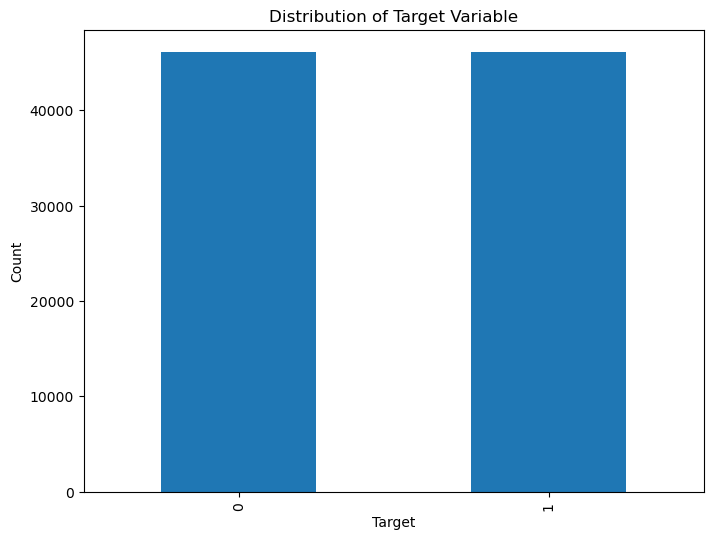

In [19]:
# Distribution of target variable
plt.figure(figsize=(8, 6))
combined_df['suitability'].value_counts().plot(kind='bar')
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

<Figure size 2000x1600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix of Features')

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
        22.5]),
 [Text(0.5, 0, 'sudem_1000m_albers_filled_wc'),
  Text(1.5, 0, 'sudem_1000m_albers_potential_solar_rad_wh2m_wc'),
  Text(2.5, 0, 'sudem_1000m_albers_twi_d8_wc'),
  Text(3.5, 0, 'sudem_1000m_albers_slope_degree_wc'),
  Text(4.5, 0, 'sudem_1000m_albers_slope_wc'),
  Text(5.5, 0, 'sudem_1000m_albers_aspect_wc'),
  Text(6.5, 0, 'sudem_1000m_albers_flow_network_wc'),
  Text(7.5, 0, 'sudem_1000m_albers_curvature_wc'),
  Text(8.5, 0, 'composite_temp_mean_1000m_k30_wc'),
  Text(9.5, 0, 'composite_temp_min_1000m_k30_wc'),
  Text(10.5, 0, 'composite_temp_max_1000m_k30_wc'),
  Text(11.5, 0, 'composite_rainfall_sum_1000m_k30_wc'),
  Text(12.5, 0, 'composite_gdd_grapes_1000m_wc'),
  Text(13.5, 0, 'composite_AETI_1000m_albers_wc'),
  Text(14.5, 0, 'nitrogen_0_to_5cm_1000m_albers_wc'),
  Text(15.5, 0, 'sand_0_to_5cm_1000m_albers_wc'),
  Te

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
        22.5]),
 [Text(0, 0.5, 'sudem_1000m_albers_filled_wc'),
  Text(0, 1.5, 'sudem_1000m_albers_potential_solar_rad_wh2m_wc'),
  Text(0, 2.5, 'sudem_1000m_albers_twi_d8_wc'),
  Text(0, 3.5, 'sudem_1000m_albers_slope_degree_wc'),
  Text(0, 4.5, 'sudem_1000m_albers_slope_wc'),
  Text(0, 5.5, 'sudem_1000m_albers_aspect_wc'),
  Text(0, 6.5, 'sudem_1000m_albers_flow_network_wc'),
  Text(0, 7.5, 'sudem_1000m_albers_curvature_wc'),
  Text(0, 8.5, 'composite_temp_mean_1000m_k30_wc'),
  Text(0, 9.5, 'composite_temp_min_1000m_k30_wc'),
  Text(0, 10.5, 'composite_temp_max_1000m_k30_wc'),
  Text(0, 11.5, 'composite_rainfall_sum_1000m_k30_wc'),
  Text(0, 12.5, 'composite_gdd_grapes_1000m_wc'),
  Text(0, 13.5, 'composite_AETI_1000m_albers_wc'),
  Text(0, 14.5, 'nitrogen_0_to_5cm_1000m_albers_wc'),
  Text(0, 15.5, 'sand_0_to_5cm_1000m_albers_wc'),
  Te

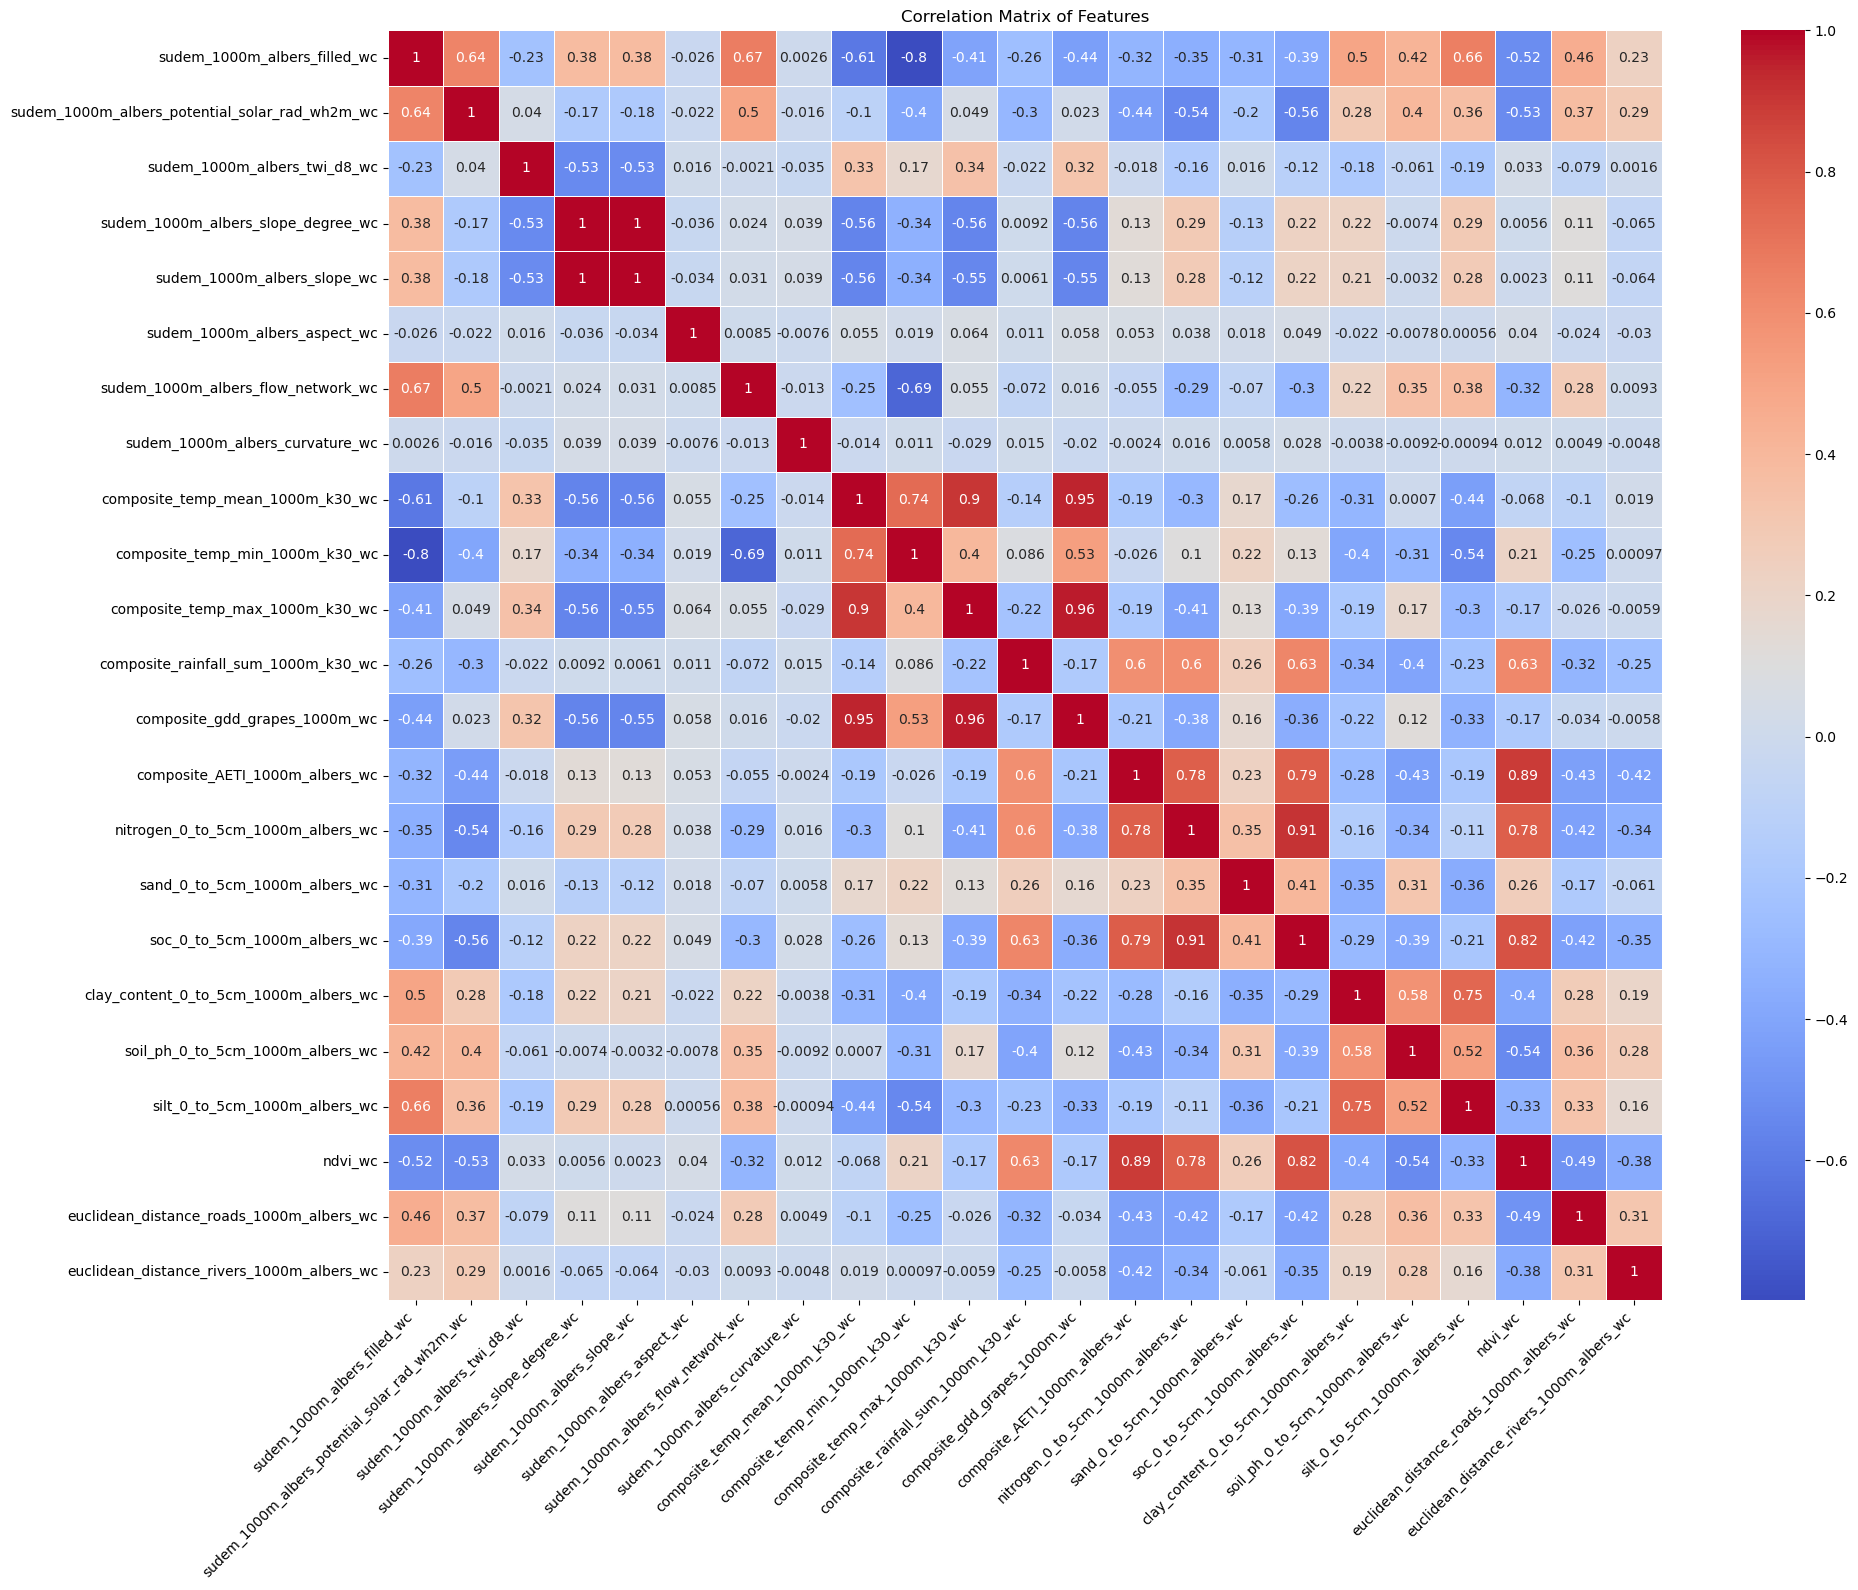

In [20]:
# Correlation matrix of features

# drop OID__, POINT_X, POINT_Y, suitability columns 
columns_to_drop = ['suitability', 'OID_', 'POINT_X', 'POINT_Y'] 
features = combined_df.drop(columns=columns_to_drop)

plt.figure(figsize=(20, 16))
correlation_matrix = features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

<Axes: >

<Axes: xlabel='sudem_1000m_albers_filled_wc', ylabel='Count'>

Text(0.5, 1.0, 'sudem_1000m_albers_filled_wc')

<Axes: >

...

<Axes: xlabel='sudem_1000m_albers_curvature_wc', ylabel='Count'>

Text(0.5, 1.0, 'sudem_1000m_albers_curvature_wc')

<Axes: >

<Axes: xlabel='composite_temp_mean_1000m_k30_wc', ylabel='Count'>

Text(0.5, 1.0, 'composite_temp_mean_1000m_k30_wc')

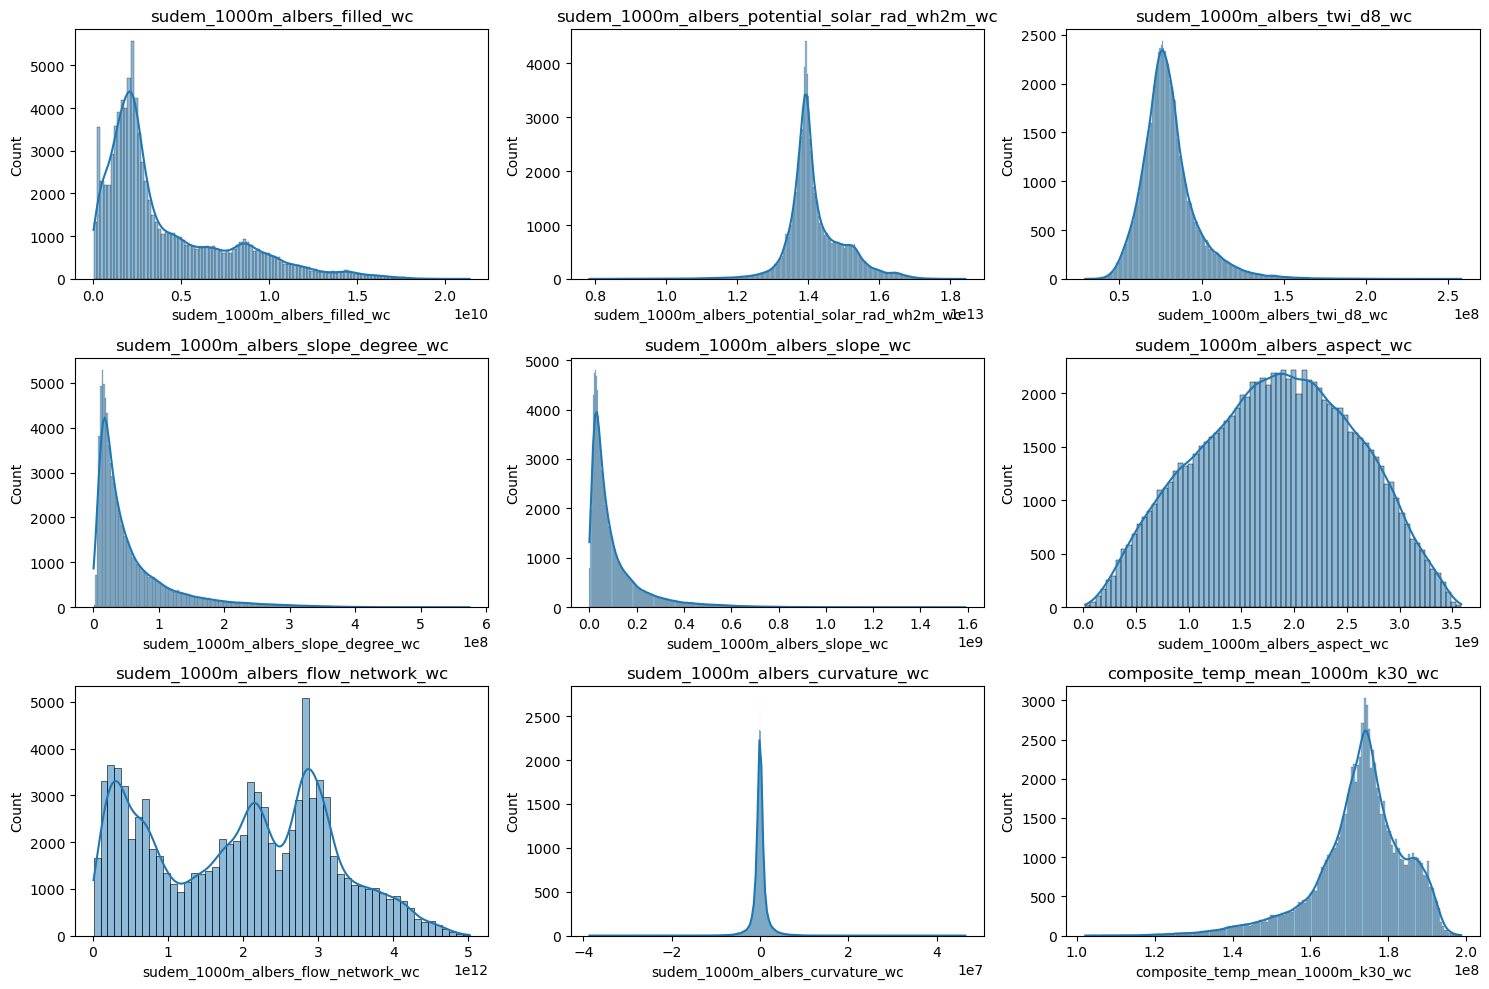

In [21]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[3:12], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

<Axes: >

<Axes: xlabel='composite_temp_min_1000m_k30_wc', ylabel='Count'>

Text(0.5, 1.0, 'composite_temp_min_1000m_k30_wc')

<Axes: >

...

<Axes: xlabel='soc_0_to_5cm_1000m_albers_wc', ylabel='Count'>

Text(0.5, 1.0, 'soc_0_to_5cm_1000m_albers_wc')

<Axes: >

<Axes: xlabel='clay_content_0_to_5cm_1000m_albers_wc', ylabel='Count'>

Text(0.5, 1.0, 'clay_content_0_to_5cm_1000m_albers_wc')

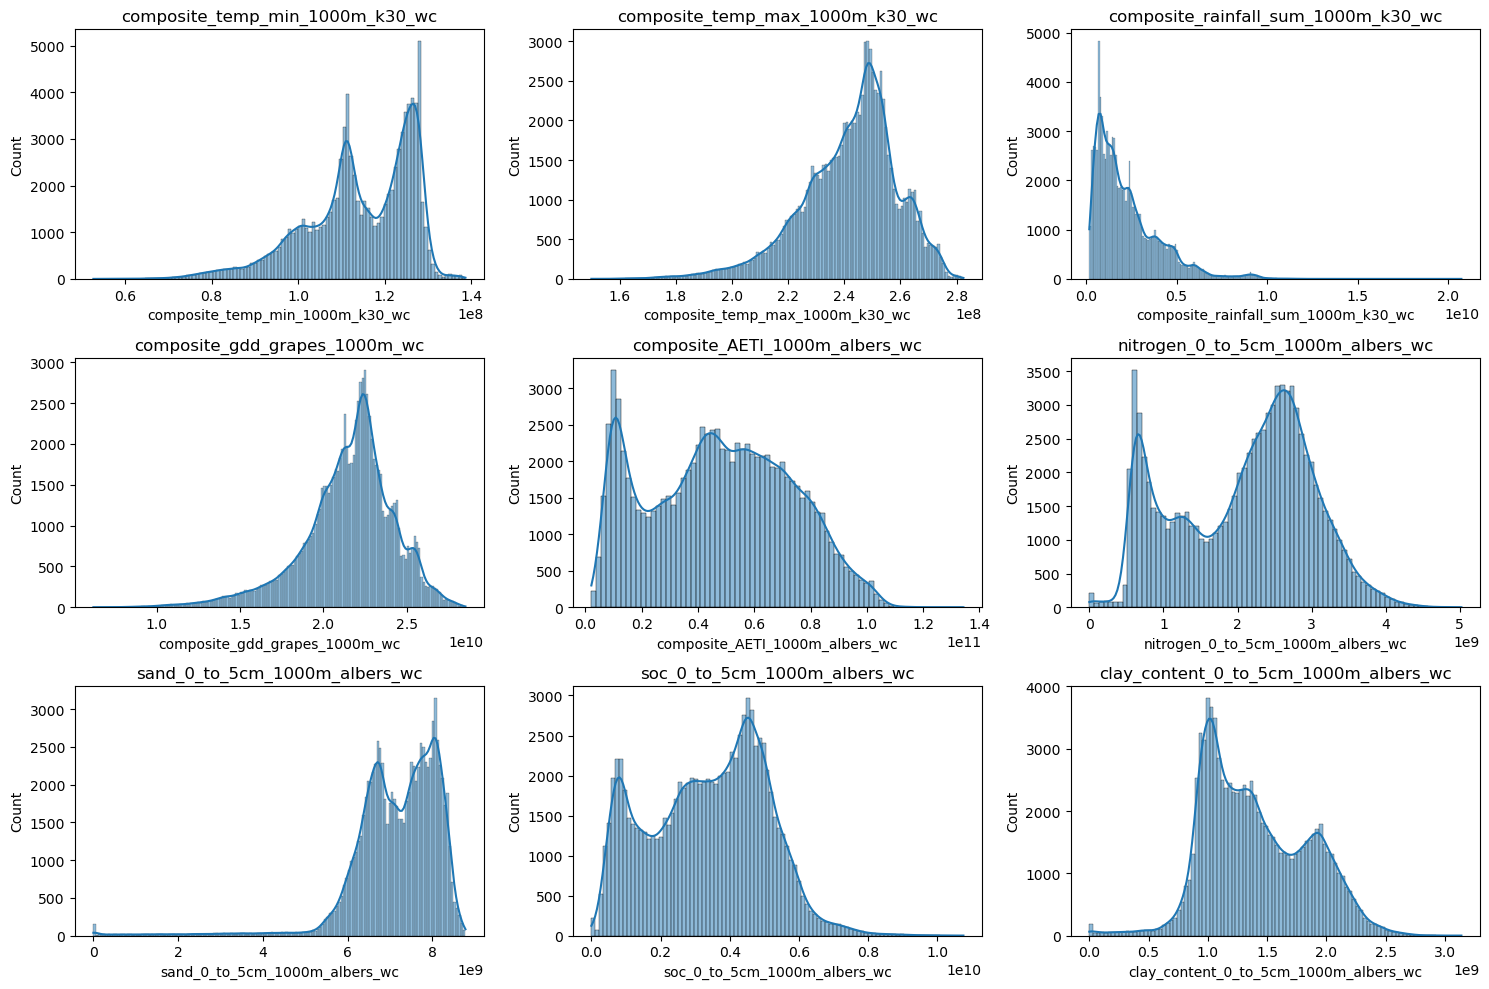

In [22]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[12:21], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

<Axes: >

<Axes: xlabel='soil_ph_0_to_5cm_1000m_albers_wc', ylabel='Count'>

Text(0.5, 1.0, 'soil_ph_0_to_5cm_1000m_albers_wc')

<Axes: >

...

<Axes: xlabel='euclidean_distance_rivers_1000m_albers_wc', ylabel='Count'>

Text(0.5, 1.0, 'euclidean_distance_rivers_1000m_albers_wc')

<Axes: >

<Axes: xlabel='suitability', ylabel='Count'>

Text(0.5, 1.0, 'suitability')

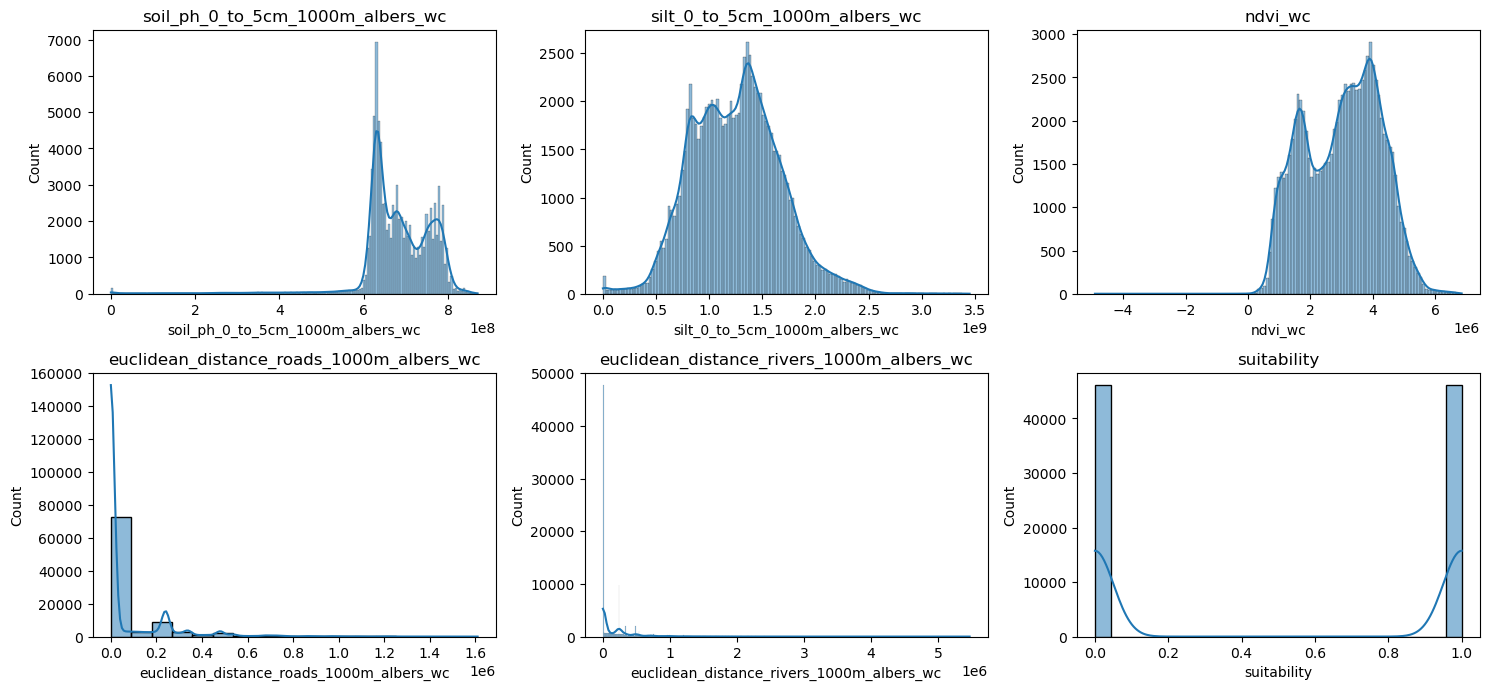

In [23]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[21:], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

Text(0.5, 1.0, 'Geographical Distribution of Points')

Text(0.5, 0, 'Longitude')

Text(0, 0.5, 'Latitude')

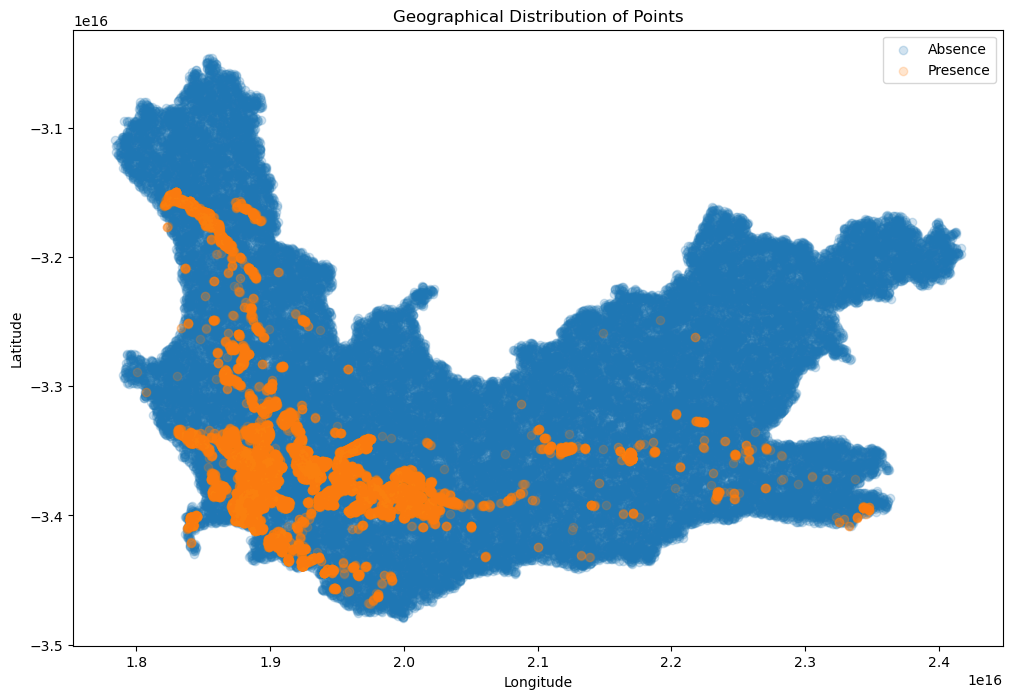

In [24]:
# Geographical distribution (if latitude and longitude are available)
plt.figure(figsize=(12, 8))
plt.scatter(combined_df[combined_df['suitability'] == 0]['POINT_X'], 
            combined_df[combined_df['suitability'] == 0]['POINT_Y'], 
            alpha=0.2, label='Absence')
plt.scatter(combined_df[combined_df['suitability'] == 1]['POINT_X'], 
            combined_df[combined_df['suitability'] == 1]['POINT_Y'], 
            alpha=0.2, label='Presence')
plt.title('Geographical Distribution of Points')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

## Model training

In [25]:
# I can potentially look at normalizing the data see the example below

# from sklearn.preprocessing import StandardScaler

# Normalizing 
# No need to normalize binary or Likert Scaled columns. 

# columns_to_normalize = df.columns[1:5] 

# Initialize the StandardScaler

# scaler = StandardScaler()

# Fit and transform the selected columns

# df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

In [26]:
# columns to drop
# I am dropping the suitability column because it is the target variable and OID column because it is an identifier and to reduce overfitting and noise 
# I can potentially drop the geometry columns as well?? 
# We can potentially drop POINT_X and POINT_Y because they are location identifiers rather than predictive features
# But if geographical location is important we can potentially keep them

# columns_to_drop = ['suitability', 'OID_', 'POINT_X', 'POINT_Y'] 

# features/ predictor variables
X = combined_df.drop(columns=columns_to_drop)

# target variable (0 and 1)
y = combined_df['suitability']




In [27]:
# Create a train/test split with 20% as test size
# random_state controls the shuffling applied to the data before applying the split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [28]:

# Initialize the XGBoost regressor
# There is also a XGBClassifier 
#  The XGBRegressor class in the XGBoost Python API is used for regression problems 

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# accuracy = accuracy_score(y_test, y_pred)

# print(f"Accuracy: {accuracy:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# Got these results when i ran the model with point_x and point_y data
# Mean Squared Error: 0.0269
# R-squared Score: 0.8923

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

Mean Squared Error: 0.0286
R-squared Score: 0.8857


## Feature importance

In [29]:
# Get feature importance
feature_importance = xgb_model.feature_importances_
feature_names = X.columns

In [30]:
# Sort features by importance
sorted_idx = np.argsort(feature_importance)
sorted_features = feature_names[sorted_idx]
sorted_features

Index(['sudem_1000m_albers_curvature_wc', 'sudem_1000m_albers_aspect_wc',
       'sudem_1000m_albers_twi_d8_wc', 'nitrogen_0_to_5cm_1000m_albers_wc',
       'soc_0_to_5cm_1000m_albers_wc',
       'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
       'composite_AETI_1000m_albers_wc', 'composite_temp_mean_1000m_k30_wc',
       'composite_rainfall_sum_1000m_k30_wc',
       'sudem_1000m_albers_flow_network_wc', 'composite_temp_min_1000m_k30_wc',
       'soil_ph_0_to_5cm_1000m_albers_wc', 'sudem_1000m_albers_slope_wc',
       'composite_gdd_grapes_1000m_wc', 'sudem_1000m_albers_filled_wc',
       'sand_0_to_5cm_1000m_albers_wc', 'sudem_1000m_albers_slope_degree_wc',
       'clay_content_0_to_5cm_1000m_albers_wc',
       'composite_temp_max_1000m_k30_wc',
       'euclidean_distance_rivers_1000m_albers_wc',
       'euclidean_distance_roads_1000m_albers_wc',
       'silt_0_to_5cm_1000m_albers_wc', 'ndvi_wc'],
      dtype='object')

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 23 artists>

([<matplotlib.axis.YTick at 0x1ea74fe9820>,
 [Text(0, 0, 'sudem_1000m_albers_curvature_wc'),
  Text(0, 1, 'sudem_1000m_albers_aspect_wc'),
  Text(0, 2, 'sudem_1000m_albers_twi_d8_wc'),
  Text(0, 3, 'nitrogen_0_to_5cm_1000m_albers_wc'),
  Text(0, 4, 'soc_0_to_5cm_1000m_albers_wc'),
  Text(0, 5, 'sudem_1000m_albers_potential_solar_rad_wh2m_wc'),
  Text(0, 6, 'composite_AETI_1000m_albers_wc'),
  Text(0, 7, 'composite_temp_mean_1000m_k30_wc'),
  Text(0, 8, 'composite_rainfall_sum_1000m_k30_wc'),
  Text(0, 9, 'sudem_1000m_albers_flow_network_wc'),
  Text(0, 10, 'composite_temp_min_1000m_k30_wc'),
  Text(0, 11, 'soil_ph_0_to_5cm_1000m_albers_wc'),
  Text(0, 12, 'sudem_1000m_albers_slope_wc'),
  Text(0, 13, 'composite_gdd_grapes_1000m_wc'),
  Text(0, 14, 'sudem_1000m_albers_filled_wc'),
  Text(0, 15, 'sand_0_to_5cm_1000m_albers_wc'),
  Text(0, 16, 'sudem_1000m_albers_slope_degree_wc'),
  Text(0, 17, 'clay_content_0_to_5cm_1000m_albers_wc'),
  Text(0, 18, 'composite_temp_max_1000m_k30_wc'),
  

Text(0.5, 0, 'Importance')

Text(0.5, 1.0, 'Feature Importance')

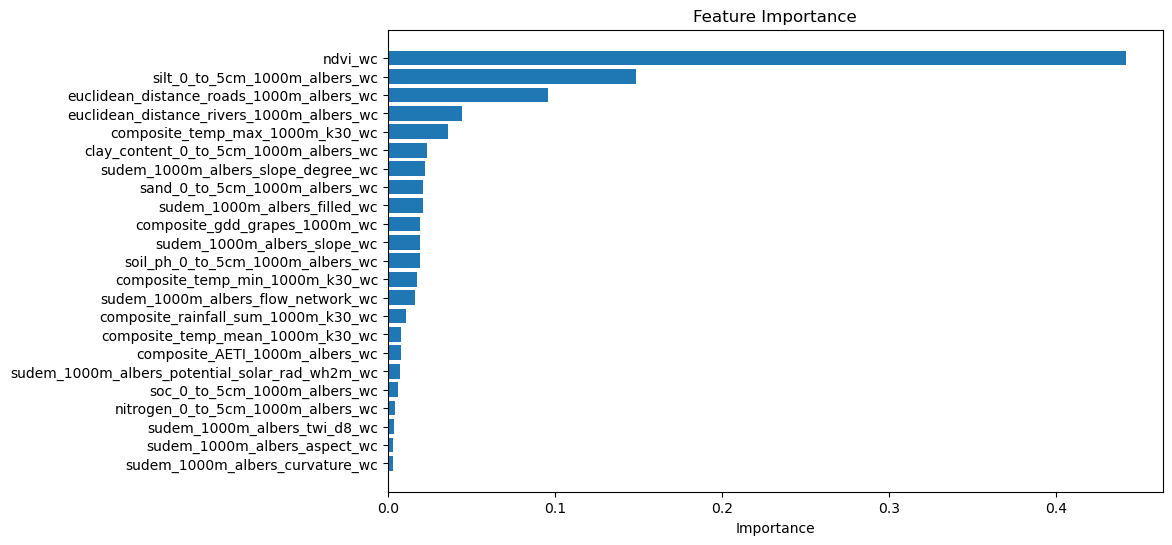

In [31]:
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_features)), sorted_features)
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

## Predicting suitability for new locations

In [32]:
# I can use the points of absence to predict new location??
# Load new data for prediction (adjust as needed)
# new_locations = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/points_data/points_of_absence_test_new.csv', delimiter=';')
# new_locations_scaled = scaler.transform(new_locations)

# Make predictions
# suitability_scores = xgb_model.predict(new_locations)

# Add predictions to the new_locations dataframe
# new_locations['suitability_score'] = suitability_scores

# Save results
# new_locations.to_csv('predicted_suitability.csv', index=False)

In [147]:
new_locations_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/points_data/western_cape_points.csv', delimiter=';')

print("New locations", new_locations_df.shape)

New locations (124719, 26)


In [148]:
print("New locations")
new_locations_df.head()
new_locations_df.describe()

New locations


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,18,"-33,025000002339254","20,453399658203125","1373555,8750000","10,1030378","2,8192158","4,1055756","286,4891968","2764,6491699","0,2575383","17,8092937","12,7749853","23,9772301","50,2829247","2116,1140137","1381,9915771","212,2704010","807,1864014","506,6420288","111,2053680","70,1265869","81,6082001","0,3210027","0,0000000","0,2519100"
1,2,18,"-33,025000002339254","22,988149642944336","1371818,8750000","9,9369183","3,0779545","4,0687332","234,9720917",NaN,NaN,"17,8084679","12,7611475","23,9920540","51,6015205","2117,1230469","1681,8825684","238,9432678","807,2391357","526,4843140","116,8121109","69,8861084","75,9487457","0,3291732","0,0000000","0,2518362"
2,3,18,"-33,025000002339254",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"17,8057690","12,7534132","23,9939995",NaN,"2116,2209473",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,18,"-33,025000002339254",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"17,8166637","12,7526712","24,0171661",NaN,"2118,6562500",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,18,"-33,025000002339254",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"17,8099804",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,OID_,POINT_X
count,124719.000000,124719.000000
mean,62360.000000,20.618174
std,36003.418449,1.691074
min,1.000000,18.000000
25%,31180.500000,19.000000
50%,62360.000000,20.000000
75%,93539.500000,22.000000
max,124719.000000,24.000000


In [149]:
new_locations_df.isnull().sum()

OID_                                                 0
POINT_X                                              0
POINT_Y                                              0
sudem_1000m_albers_filled_wc                      1759
sudem_1000m_albers_potential_solar_rad_wh2m_wc    1771
sudem_1000m_albers_twi_d8_wc                      1773
sudem_1000m_albers_slope_degree_wc                1773
sudem_1000m_albers_slope_wc                       1773
sudem_1000m_albers_aspect_wc                      1768
sudem_1000m_albers_flow_network_wc                1803
sudem_1000m_albers_curvature_wc                   1803
composite_temp_mean_1000m_k30_wc                     0
composite_temp_min_1000m_k30_wc                   2053
composite_temp_max_1000m_k30_wc                   2053
composite_rainfall_sum_1000m_k30_wc               1911
composite_gdd_grapes_1000m_wc                     2053
composite_AETI_1000m_albers_wc                    1813
nitrogen_0_to_5cm_1000m_albers_wc                 1850
sand_0_to_

In [150]:
new_locations_df.dtypes

OID_                                               int64
POINT_X                                            int64
POINT_Y                                           object
sudem_1000m_albers_filled_wc                      object
sudem_1000m_albers_potential_solar_rad_wh2m_wc    object
sudem_1000m_albers_twi_d8_wc                      object
sudem_1000m_albers_slope_degree_wc                object
sudem_1000m_albers_slope_wc                       object
sudem_1000m_albers_aspect_wc                      object
sudem_1000m_albers_flow_network_wc                object
sudem_1000m_albers_curvature_wc                   object
composite_temp_mean_1000m_k30_wc                  object
composite_temp_min_1000m_k30_wc                   object
composite_temp_max_1000m_k30_wc                   object
composite_rainfall_sum_1000m_k30_wc               object
composite_gdd_grapes_1000m_wc                     object
composite_AETI_1000m_albers_wc                    object
nitrogen_0_to_5cm_1000m_albers_

In [151]:
# Converting the columns to float
columns_to_convert_for_new_locations = [ 'POINT_Y', 'sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
                        'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc', 'sudem_1000m_albers_slope_wc',
                        'sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
                        'composite_temp_mean_1000m_k30_wc','composite_temp_min_1000m_k30_wc', 'composite_temp_max_1000m_k30_wc',
                        'composite_rainfall_sum_1000m_k30_wc', 'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc',
                        'nitrogen_0_to_5cm_1000m_albers_wc', 'sand_0_to_5cm_1000m_albers_wc', 'soc_0_to_5cm_1000m_albers_wc',
                        'clay_content_0_to_5cm_1000m_albers_wc', 'soil_ph_0_to_5cm_1000m_albers_wc', 'silt_0_to_5cm_1000m_albers_wc',
                        'ndvi_wc', 'euclidean_distance_roads_1000m_albers_wc', 'euclidean_distance_rivers_1000m_albers_wc']

for col in columns_to_convert_for_new_locations:
    new_locations_df[col] = clean_and_convert(new_locations_df[col])

In [152]:
# checking the data types again

new_locations_df.dtypes

OID_                                                int64
POINT_X                                             int64
POINT_Y                                           float64
sudem_1000m_albers_filled_wc                      float64
sudem_1000m_albers_potential_solar_rad_wh2m_wc    float64
sudem_1000m_albers_twi_d8_wc                      float64
sudem_1000m_albers_slope_degree_wc                float64
sudem_1000m_albers_slope_wc                       float64
sudem_1000m_albers_aspect_wc                      float64
sudem_1000m_albers_flow_network_wc                float64
sudem_1000m_albers_curvature_wc                   float64
composite_temp_mean_1000m_k30_wc                  float64
composite_temp_min_1000m_k30_wc                   float64
composite_temp_max_1000m_k30_wc                   float64
composite_rainfall_sum_1000m_k30_wc               float64
composite_gdd_grapes_1000m_wc                     float64
composite_AETI_1000m_albers_wc                    float64
nitrogen_0_to_

In [153]:
new_locations_df

# creating a new df called new_locations_df_2 to use for the csv file
new_locations_df_2 = new_locations_df.copy()

new_locations_df_2

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,18,-3.302500e+16,2.045340e+16,1.373556e+13,101030378.0,28192158.0,41055756.0,2.864892e+09,2.764649e+10,2575383.0,178092937.0,127749853.0,239772301.0,502829247.0,2.116114e+10,1.381992e+10,2.122704e+09,8.071864e+09,5.066420e+09,1.112054e+09,701265869.0,8.160820e+08,3210027.0,0.0,2519100.0
1,2,18,-3.302500e+16,2.298815e+16,1.371819e+13,99369183.0,30779545.0,40687332.0,2.349721e+09,NaN,NaN,178084679.0,127611475.0,239920540.0,516015205.0,2.117123e+10,1.681883e+10,2.389433e+09,8.072391e+09,5.264843e+09,1.168121e+09,698861084.0,7.594875e+08,3291732.0,0.0,2518362.0
2,3,18,-3.302500e+16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178057690.0,127534132.0,239939995.0,NaN,2.116221e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,18,-3.302500e+16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178166637.0,127526712.0,240171661.0,NaN,2.118656e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,18,-3.302500e+16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178099804.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124714,124715,19,-3.120500e+16,2.354458e+17,1.455278e+13,75298700.0,9835243.0,17026721.0,1.262276e+09,1.511468e+12,294244.0,192737522.0,126571674.0,274310246.0,753509369.0,2.565648e+10,4.217812e+09,8.753929e+08,7.661027e+09,7.768539e+08,1.277692e+09,808773041.0,1.061489e+09,1241932.0,172412.0,1132412.0
124715,124716,19,-3.120500e+16,2.408462e+17,1.458314e+13,87656193.0,13273245.0,23162935.0,2.442744e+09,1.520330e+12,201967.0,192792912.0,126488991.0,274522057.0,764138107.0,2.568864e+10,3.855027e+09,9.397031e+08,7.719128e+09,8.970396e+08,1.154226e+09,800000000.0,1.126923e+09,1238185.0,240000.0,1200000.0
124716,124717,19,-3.120500e+16,2.537488e+17,1.455726e+13,81614685.0,23157809.0,39974215.0,2.468819e+09,1.531074e+12,322212.0,192852268.0,126409683.0,274737396.0,773950806.0,2.572175e+10,4.020746e+09,9.533910e+08,7.723950e+09,8.936301e+08,1.169347e+09,798343506.0,1.100893e+09,1188042.0,240000.0,1200000.0
124717,124718,19,-3.120500e+16,2.710489e+17,1.466812e+13,78057132.0,10897772.0,19023145.0,1.981758e+09,1.552634e+12,-35838.0,192493076.0,126112146.0,274268398.0,782808228.0,2.564883e+10,5.144753e+09,9.760077e+08,7.676423e+09,9.268220e+08,1.221506e+09,790331497.0,1.107319e+09,1144868.0,427875.0,1333792.0


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,18,-3.302500e+16,2.045340e+16,1.373556e+13,101030378.0,28192158.0,41055756.0,2.864892e+09,2.764649e+10,2575383.0,178092937.0,127749853.0,239772301.0,502829247.0,2.116114e+10,1.381992e+10,2.122704e+09,8.071864e+09,5.066420e+09,1.112054e+09,701265869.0,8.160820e+08,3210027.0,0.0,2519100.0
1,2,18,-3.302500e+16,2.298815e+16,1.371819e+13,99369183.0,30779545.0,40687332.0,2.349721e+09,NaN,NaN,178084679.0,127611475.0,239920540.0,516015205.0,2.117123e+10,1.681883e+10,2.389433e+09,8.072391e+09,5.264843e+09,1.168121e+09,698861084.0,7.594875e+08,3291732.0,0.0,2518362.0
2,3,18,-3.302500e+16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178057690.0,127534132.0,239939995.0,NaN,2.116221e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,18,-3.302500e+16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178166637.0,127526712.0,240171661.0,NaN,2.118656e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,18,-3.302500e+16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178099804.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124714,124715,19,-3.120500e+16,2.354458e+17,1.455278e+13,75298700.0,9835243.0,17026721.0,1.262276e+09,1.511468e+12,294244.0,192737522.0,126571674.0,274310246.0,753509369.0,2.565648e+10,4.217812e+09,8.753929e+08,7.661027e+09,7.768539e+08,1.277692e+09,808773041.0,1.061489e+09,1241932.0,172412.0,1132412.0
124715,124716,19,-3.120500e+16,2.408462e+17,1.458314e+13,87656193.0,13273245.0,23162935.0,2.442744e+09,1.520330e+12,201967.0,192792912.0,126488991.0,274522057.0,764138107.0,2.568864e+10,3.855027e+09,9.397031e+08,7.719128e+09,8.970396e+08,1.154226e+09,800000000.0,1.126923e+09,1238185.0,240000.0,1200000.0
124716,124717,19,-3.120500e+16,2.537488e+17,1.455726e+13,81614685.0,23157809.0,39974215.0,2.468819e+09,1.531074e+12,322212.0,192852268.0,126409683.0,274737396.0,773950806.0,2.572175e+10,4.020746e+09,9.533910e+08,7.723950e+09,8.936301e+08,1.169347e+09,798343506.0,1.100893e+09,1188042.0,240000.0,1200000.0
124717,124718,19,-3.120500e+16,2.710489e+17,1.466812e+13,78057132.0,10897772.0,19023145.0,1.981758e+09,1.552634e+12,-35838.0,192493076.0,126112146.0,274268398.0,782808228.0,2.564883e+10,5.144753e+09,9.760077e+08,7.676423e+09,9.268220e+08,1.221506e+09,790331497.0,1.107319e+09,1144868.0,427875.0,1333792.0


In [154]:
# interpolate the columns with null values

columns_to_interpolate_for_new_locations = ['sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
                                            'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc', 'sudem_1000m_albers_slope_wc',
                                            'sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
                                            'composite_temp_min_1000m_k30_wc', 'composite_temp_max_1000m_k30_wc',
                                            'composite_rainfall_sum_1000m_k30_wc', 'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc',
                                            'nitrogen_0_to_5cm_1000m_albers_wc', 'sand_0_to_5cm_1000m_albers_wc', 'soc_0_to_5cm_1000m_albers_wc',
                                            'clay_content_0_to_5cm_1000m_albers_wc', 'soil_ph_0_to_5cm_1000m_albers_wc', 'silt_0_to_5cm_1000m_albers_wc',
                                            'ndvi_wc', 'euclidean_distance_roads_1000m_albers_wc', 'euclidean_distance_rivers_1000m_albers_wc']

interpolate_columns(new_locations_df, columns_to_interpolate_for_new_locations)

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,18,-3.302500e+16,2.045340e+16,1.373556e+13,101030378.0,28192158.0,41055756.0,2.864892e+09,2.764649e+10,2.575383e+06,178092937.0,127749853.0,239772301.0,502829247.0,2.116114e+10,1.381992e+10,2.122704e+09,8.071864e+09,5.066420e+09,1.112054e+09,701265869.0,8.160820e+08,3210027.00,0.0,2519100.0
1,2,18,-3.302500e+16,2.298815e+16,1.371819e+13,99369183.0,30779545.0,40687332.0,2.349721e+09,2.639114e+10,1.996242e+06,178084679.0,127611475.0,239920540.0,516015205.0,2.117123e+10,1.681883e+10,2.389433e+09,8.072391e+09,5.264843e+09,1.168121e+09,698861084.0,7.594875e+08,3291732.00,0.0,2518362.0
2,3,18,-3.302500e+16,2.122724e+16,1.372884e+13,93516789.8,28385717.6,38845235.2,2.305502e+09,2.513579e+10,1.417101e+06,178057690.0,127534132.0,239939995.0,556070663.2,2.116221e+10,1.676782e+10,2.339503e+09,8.090798e+09,5.095749e+09,1.174458e+09,701088867.2,7.340798e+08,3106964.25,0.0,2472130.4
3,4,18,-3.302500e+16,1.946632e+16,1.373949e+13,87664396.6,25991890.2,37003138.4,2.261284e+09,2.388045e+10,8.379595e+05,178166637.0,127526712.0,240171661.0,596126121.4,2.118656e+10,1.671682e+10,2.289574e+09,8.109204e+09,4.926655e+09,1.180796e+09,703316650.4,7.086721e+08,2922196.50,0.0,2425898.8
4,5,18,-3.302500e+16,1.770541e+16,1.375015e+13,81812003.4,23598062.8,35161041.6,2.217065e+09,2.262510e+10,2.588183e+05,178099804.0,126554331.5,239383249.0,636181579.6,2.100266e+10,1.666582e+10,2.239644e+09,8.127610e+09,4.757561e+09,1.187133e+09,705544433.6,6.832644e+08,2737428.75,0.0,2379667.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124714,124715,19,-3.120500e+16,2.354458e+17,1.455278e+13,75298700.0,9835243.0,17026721.0,1.262276e+09,1.511468e+12,2.942440e+05,192737522.0,126571674.0,274310246.0,753509369.0,2.565648e+10,4.217812e+09,8.753929e+08,7.661027e+09,7.768539e+08,1.277692e+09,808773041.0,1.061489e+09,1241932.00,172412.0,1132412.0
124715,124716,19,-3.120500e+16,2.408462e+17,1.458314e+13,87656193.0,13273245.0,23162935.0,2.442744e+09,1.520330e+12,2.019670e+05,192792912.0,126488991.0,274522057.0,764138107.0,2.568864e+10,3.855027e+09,9.397031e+08,7.719128e+09,8.970396e+08,1.154226e+09,800000000.0,1.126923e+09,1238185.00,240000.0,1200000.0
124716,124717,19,-3.120500e+16,2.537488e+17,1.455726e+13,81614685.0,23157809.0,39974215.0,2.468819e+09,1.531074e+12,3.222120e+05,192852268.0,126409683.0,274737396.0,773950806.0,2.572175e+10,4.020746e+09,9.533910e+08,7.723950e+09,8.936301e+08,1.169347e+09,798343506.0,1.100893e+09,1188042.00,240000.0,1200000.0
124717,124718,19,-3.120500e+16,2.710489e+17,1.466812e+13,78057132.0,10897772.0,19023145.0,1.981758e+09,1.552634e+12,-3.583800e+04,192493076.0,126112146.0,274268398.0,782808228.0,2.564883e+10,5.144753e+09,9.760077e+08,7.676423e+09,9.268220e+08,1.221506e+09,790331497.0,1.107319e+09,1144868.00,427875.0,1333792.0


In [155]:
new_locations_df.isnull().sum()

OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_k30_wc                  0
composite_temp_min_1000m_k30_wc                   0
composite_temp_max_1000m_k30_wc                   0
composite_rainfall_sum_1000m_k30_wc               0
composite_gdd_grapes_1000m_wc                     0
composite_AETI_1000m_albers_wc                    0
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

In [156]:
# Make predictions
columns_to_drop_2 = ['OID_', 'POINT_X', 'POINT_Y']

new_locations_df.drop(columns=columns_to_drop_2, inplace=True)
suitability_scores = xgb_model.predict(new_locations_df)

In [157]:
# Add predictions to the new_locations dataframe
new_locations_df['suitability_score'] = suitability_scores

In [158]:
# Save results
new_locations_df.to_csv('wc_predicted_suitability.csv', index=False)

In [159]:
wc_predicted_suitability = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/wc_predicted_suitability.csv')        

In [160]:
wc_predicted_suitability['suitability_score'].describe()

count    124719.000000
mean          0.037247
std           0.153013
min          -1.100642
25%          -0.013564
50%           0.001606
75%           0.056922
max           1.107785
Name: suitability_score, dtype: float64

In [161]:
wc_vineyard_locations = wc_predicted_suitability['suitability_score']

In [162]:
wc_vineyard_locations.to_csv('only_suitability_score_wc.csv', index=False)
new_locations_df_2

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,18,-3.302500e+16,2.045340e+16,1.373556e+13,101030378.0,28192158.0,41055756.0,2.864892e+09,2.764649e+10,2575383.0,178092937.0,127749853.0,239772301.0,502829247.0,2.116114e+10,1.381992e+10,2.122704e+09,8.071864e+09,5.066420e+09,1.112054e+09,701265869.0,8.160820e+08,3210027.0,0.0,2519100.0
1,2,18,-3.302500e+16,2.298815e+16,1.371819e+13,99369183.0,30779545.0,40687332.0,2.349721e+09,NaN,NaN,178084679.0,127611475.0,239920540.0,516015205.0,2.117123e+10,1.681883e+10,2.389433e+09,8.072391e+09,5.264843e+09,1.168121e+09,698861084.0,7.594875e+08,3291732.0,0.0,2518362.0
2,3,18,-3.302500e+16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178057690.0,127534132.0,239939995.0,NaN,2.116221e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,18,-3.302500e+16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178166637.0,127526712.0,240171661.0,NaN,2.118656e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,18,-3.302500e+16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178099804.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124714,124715,19,-3.120500e+16,2.354458e+17,1.455278e+13,75298700.0,9835243.0,17026721.0,1.262276e+09,1.511468e+12,294244.0,192737522.0,126571674.0,274310246.0,753509369.0,2.565648e+10,4.217812e+09,8.753929e+08,7.661027e+09,7.768539e+08,1.277692e+09,808773041.0,1.061489e+09,1241932.0,172412.0,1132412.0
124715,124716,19,-3.120500e+16,2.408462e+17,1.458314e+13,87656193.0,13273245.0,23162935.0,2.442744e+09,1.520330e+12,201967.0,192792912.0,126488991.0,274522057.0,764138107.0,2.568864e+10,3.855027e+09,9.397031e+08,7.719128e+09,8.970396e+08,1.154226e+09,800000000.0,1.126923e+09,1238185.0,240000.0,1200000.0
124716,124717,19,-3.120500e+16,2.537488e+17,1.455726e+13,81614685.0,23157809.0,39974215.0,2.468819e+09,1.531074e+12,322212.0,192852268.0,126409683.0,274737396.0,773950806.0,2.572175e+10,4.020746e+09,9.533910e+08,7.723950e+09,8.936301e+08,1.169347e+09,798343506.0,1.100893e+09,1188042.0,240000.0,1200000.0
124717,124718,19,-3.120500e+16,2.710489e+17,1.466812e+13,78057132.0,10897772.0,19023145.0,1.981758e+09,1.552634e+12,-35838.0,192493076.0,126112146.0,274268398.0,782808228.0,2.564883e+10,5.144753e+09,9.760077e+08,7.676423e+09,9.268220e+08,1.221506e+09,790331497.0,1.107319e+09,1144868.0,427875.0,1333792.0


In [163]:
import geopandas as gpd
from shapely.geometry import Point

In [164]:
location_columns = ['POINT_X', 'POINT_Y']
merged_df = pd.concat([wc_vineyard_locations, new_locations_df_2[location_columns]], axis=1)

merged_df

,suitability_score,POINT_X,POINT_Y
0,0.089752,18,-3.302500e+16
1,0.275660,18,-3.302500e+16
2,0.276194,18,-3.302500e+16
3,0.371824,18,-3.302500e+16
4,0.476599,18,-3.302500e+16
...,...,...,...
124714,-0.003315,19,-3.120500e+16
124715,0.183749,19,-3.120500e+16
124716,0.085797,19,-3.120500e+16
124717,-0.016585,19,-3.120500e+16


In [165]:
merged_df.isnull().sum()

suitability_score    0
POINT_X              0
POINT_Y              0
dtype: int64

In [167]:
# Step 4: Create a geometry column
geometry = [Point(xy) for xy in zip(merged_df['POINT_X'], merged_df['POINT_Y'])]

In [168]:
# Step 5: Create a GeoDataFrame
gdf = gpd.GeoDataFrame(merged_df, geometry=geometry)

In [169]:
# Step 6: Set the coordinate reference system (CRS)
gdf.set_crs(epsg=4326, inplace=True)

,suitability_score,POINT_X,POINT_Y,geometry
0,0.089752,18,-3.302500e+16,POINT (18.00000 -33025000002339256.00000)
1,0.275660,18,-3.302500e+16,POINT (18.00000 -33025000002339256.00000)
2,0.276194,18,-3.302500e+16,POINT (18.00000 -33025000002339256.00000)
3,0.371824,18,-3.302500e+16,POINT (18.00000 -33025000002339256.00000)
4,0.476599,18,-3.302500e+16,POINT (18.00000 -33025000002339256.00000)
...,...,...,...,...
124714,-0.003315,19,-3.120500e+16,POINT (19.00000 -31205000002381608.00000)
124715,0.183749,19,-3.120500e+16,POINT (19.00000 -31205000002381608.00000)
124716,0.085797,19,-3.120500e+16,POINT (19.00000 -31205000002381608.00000)
124717,-0.016585,19,-3.120500e+16,POINT (19.00000 -31205000002381608.00000)


In [170]:
gdf.to_file('output_shapefile.shp')